_______________________________________________________________________________________________________
# Credit Card Fraud Detection - Exploratory Data Analysis (EDA)
_______________________________________________________________________________________________________

## Dataset: 

- European cardholders transactions (Sept 2013) 

- 284,807 transactions | 492 fraud cases (~0.17%) 

- Highly imbalanced dataset

## Features: 

- V1 - V28 : Anonymized (PCA-transformed for privacy) 

- Time : Seconds elapsed between transactions 

- Amount : Transaction amount  

- Class : Target → 1 = Fraud | 0 = Not Fraud

## EDA Goals:
- Understand fraud vs non-fraud distribution
- Explore feature relationships and patterns
- Identify useful insights for the modeling phase

## Note:
- Most features are anonymized, so analysis will be
- practical and focused on what helps modeling

## Sections:
- 1. Load and Inspect the Data
- 2. Dataset Feature Descriptions
- 3. Data Cleaning and Preprocessing
- 4. Feature Analysis and Relationships

_________________________________________________________________________________________________

## Load and Inspect the Data

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [60]:
import warnings
# ignore FutureWarnings and UserWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [61]:
df = pd.read_csv("fraud_train.csv")
df.head().T

,0,1,2,3,4
Time,119191.000000,71750.000000,151977.000000,55709.000000,66654.000000
V1,2.052427,1.220356,0.892824,-3.146021,1.194996
V2,-0.133236,-0.159191,-1.440698,2.247634,-0.007495
V3,-1.740621,-0.444349,-0.637940,0.901397,0.301285
V4,0.277935,-0.094437,3.912871,0.146162,0.750199
V5,0.337999,0.104457,0.099291,-2.109360,-0.297494
V6,-0.826933,-0.345790,2.433288,-0.148312,-0.405836
V7,0.334629,0.170867,-0.308891,-1.533191,0.060410
V8,-0.227039,-0.094996,0.603227,2.073663,-0.150482
V9,0.267655,0.187572,-0.113826,0.499394,0.400860


In [62]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,170884.0,94966.107886,47464.723773,0.000000,54348.000000,84923.500000,139404.000000,172792.000000
V1,170884.0,-0.001070,1.958944,-46.855047,-0.922071,0.016603,1.316250,2.451888
V2,170884.0,-0.000904,1.650481,-63.344698,-0.599127,0.065839,0.802518,22.057729
V3,170884.0,-0.002722,1.521820,-48.325589,-0.896376,0.177007,1.028302,4.226108
V4,170884.0,-0.002603,1.416490,-5.683171,-0.848978,-0.020895,0.738812,16.875344
V5,170884.0,0.000151,1.394123,-113.743307,-0.691840,-0.054185,0.612154,34.099309
V6,170884.0,0.000779,1.338331,-23.496714,-0.768986,-0.274228,0.400359,73.301626
V7,170884.0,-0.000811,1.260122,-43.557242,-0.554440,0.040417,0.569221,120.589494
V8,170884.0,-0.002327,1.208709,-73.216718,-0.209596,0.021461,0.326026,18.282168
V9,170884.0,-0.000622,1.098393,-13.434066,-0.642036,-0.051777,0.595095,10.392889


In [63]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [64]:
df.Class.value_counts()

Class
0    170579
1       305
Name: count, dtype: int64

### - Class distribution: 170,579 legitimate vs 305 fraud (0.18%)
### - Severe class imbalance - needs to be handled before modeling!!

In [65]:
df.shape

(170884, 31)

In [66]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

## Dataset Feature Descriptions
- Time: seconds elapsed since the first transaction in the dataset
- V1-V28: anonymized features generated via PCA to protect user privacy
- Amount: the transaction value in monetary terms
- Class: target variable → 0 = legitimate transaction, 1 = fraudulent transaction

## Data Cleaning and Preprocessing

### Handling Missing Values

In [67]:
df.isna().sum().value_counts()

0    31
Name: count, dtype: int64

We have no missing values in the dataset.

### Handling Duplicates

In [68]:
df.duplicated().value_counts()

False    170436
True        448
Name: count, dtype: int64

In [69]:
df[df.Class == 1].duplicated().value_counts()

False    297
True       8
Name: count, dtype: int64

- 448 duplicated rows found (including 8 fraud transactions)
- dropping duplicates to avoid bias in the model

In [70]:
df = df.drop_duplicates()

### Handling Outliers and Skewed Distributions

- KDE plot shows the distribution shape of each feature
- helps identify if the data is skewed or normally distributed

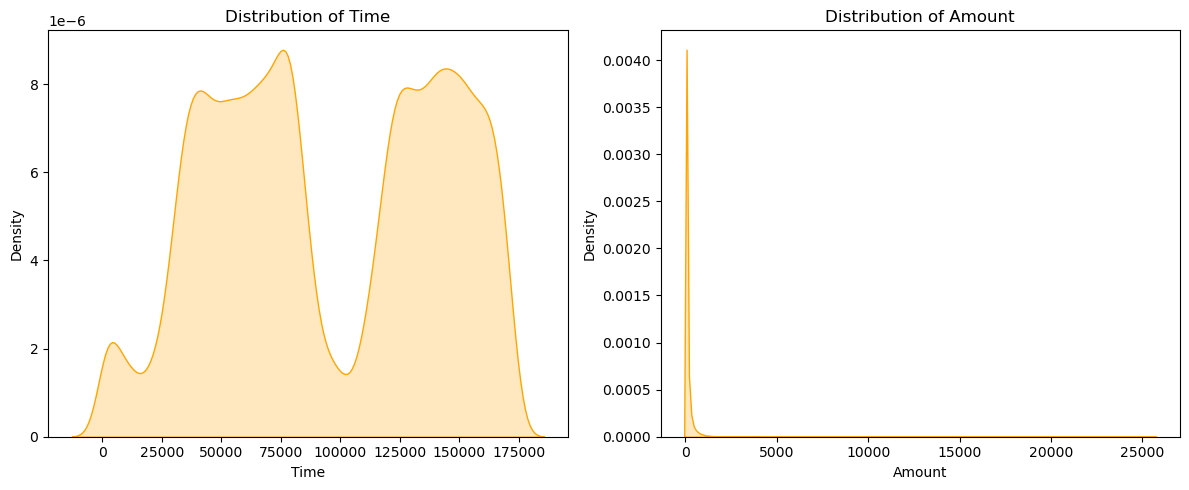

In [71]:
plt.figure(figsize=(12, 5))

# Time
plt.subplot(1, 2, 1)
sns.kdeplot(df['Time'], fill=True, color='orange')
plt.title('Distribution of Time')

# Amount
plt.subplot(1, 2, 2)
sns.kdeplot(df['Amount'], fill=True, color='orange')
plt.title('Distribution of Amount')

plt.tight_layout()
plt.show()

- Time: (natural distribution, no transformation needed)
    bimodal distribution → data spans 2 days (peaks = daytime, dip = nighttime)
- Amount: highly right-skewed → most transactions are small with few large outliers
    (log transformation will be considered during modeling)
- for now, keeping the original Amount column for analysisis

In [72]:
df["log_Amount"] = np.log1p(df["Amount"])

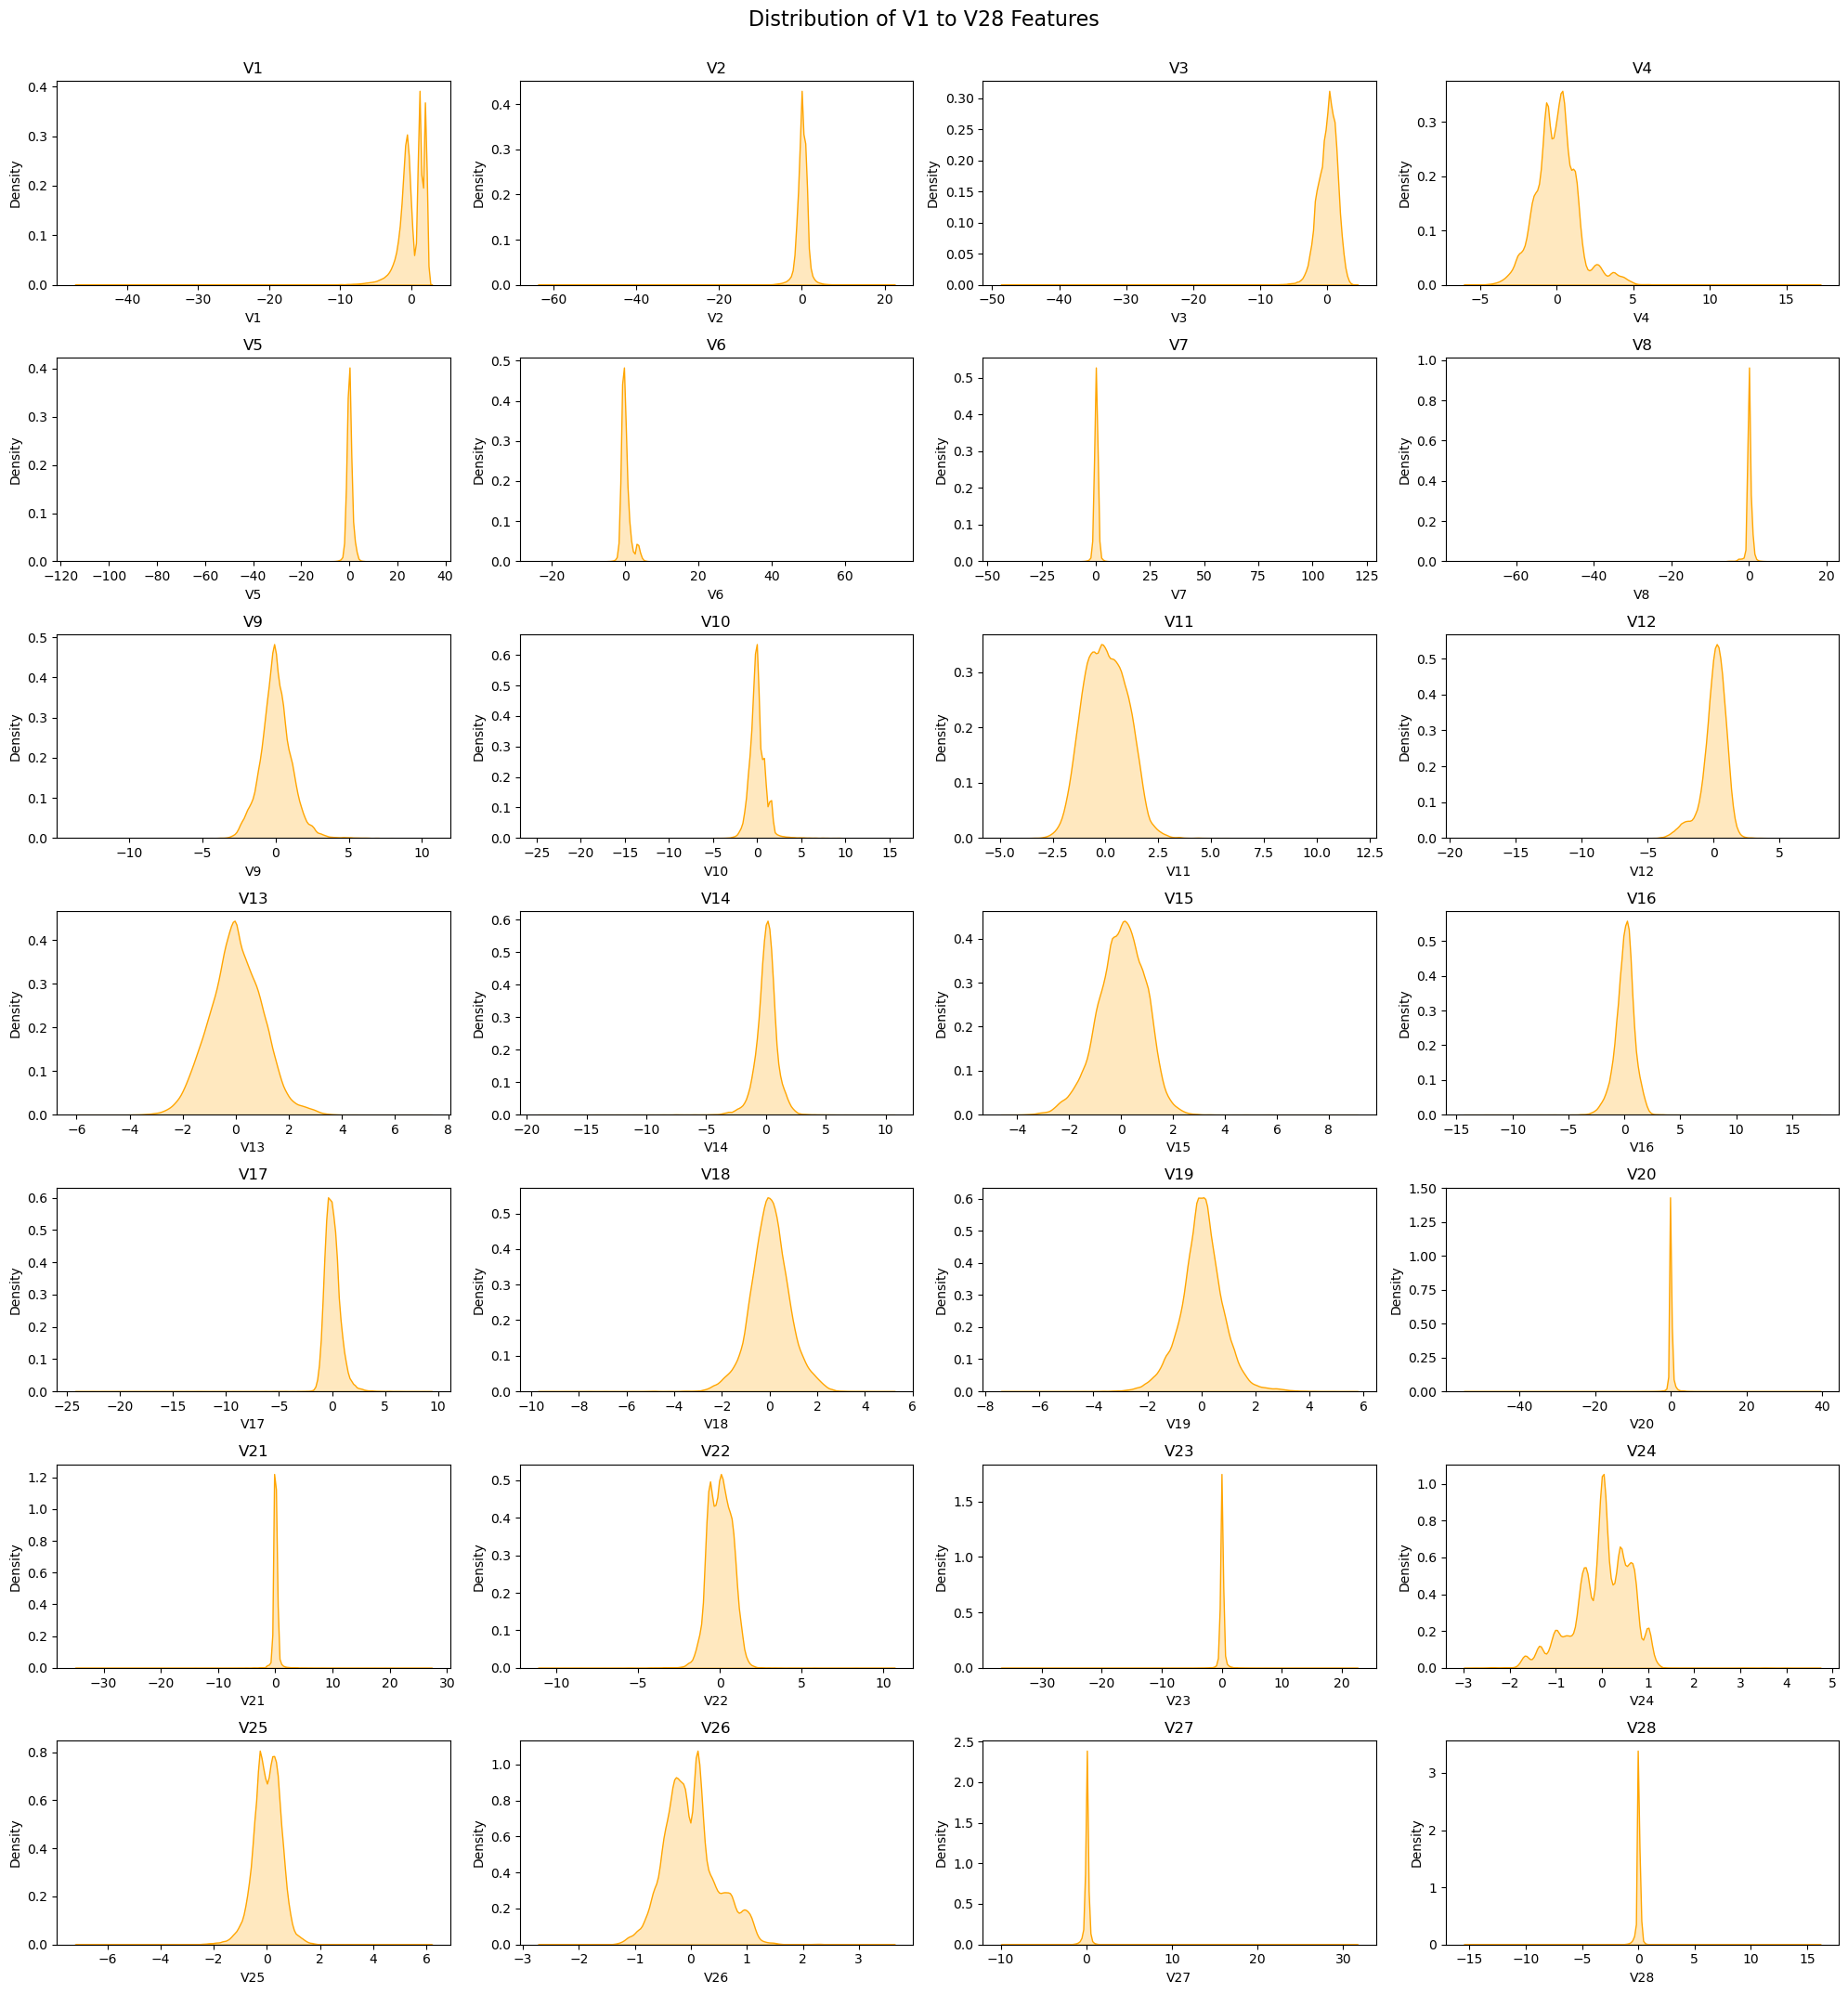

In [73]:
v_features = [f'V{i}' for i in range(1, 29)]
n_cols = 4
n_rows = int(np.ceil(len(v_features) / n_cols))

plt.figure(figsize=(20, n_rows * 3))

for idx, feature in enumerate(v_features, 1):
    plt.subplot(n_rows, n_cols, idx)
    sns.kdeplot(df[feature], fill=True, color='orange')
    plt.title(feature)
    plt.tight_layout()

plt.suptitle('Distribution of V1 to V28 Features', fontsize=16, y=1.02)
plt.show()

- plotting KDE distribution for all V1-V28 features
- V5, V6, V7, V8, V20, V21, V23, V27, V28 are highly skewed-  log transformation may help models sensitive to feature distributions- comparing correlation matrices before and after transformation to evaluate impact on relationship with target variable (Class)ss)

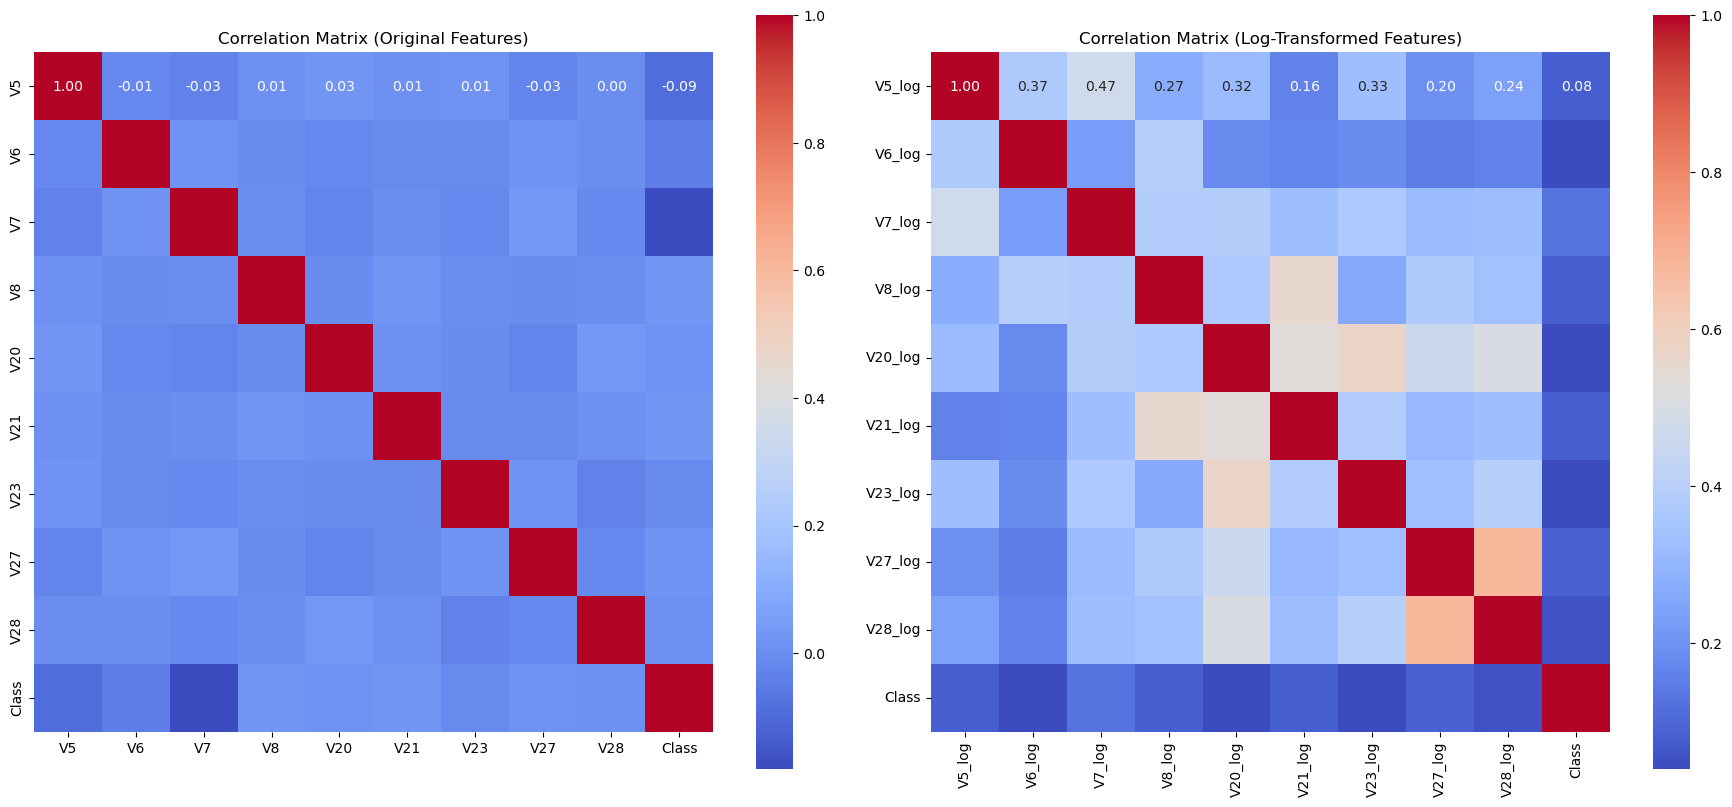

In [74]:
# Define features and create log-transformed versions
features = ['V5', 'V6', 'V7', 'V8', 'V20', 'V21', 'V23', 'V27', 'V28']

df_log = df.copy()
for col in features:
    df_log[f'{col}_log'] = np.log1p(df_log[col].abs())  # Use abs to avoid log(negative)

# Create correlation matrices
original_corr = df[features + ['Class']].corr()
log_corr = df_log[[f'{col}_log' for col in features] + ['Class']].corr()

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(original_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, ax=axes[0])
axes[0].set_title('Correlation Matrix (Original Features)')

sns.heatmap(log_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True, ax=axes[1])
axes[1].set_title('Correlation Matrix (Log-Transformed Features)')

plt.tight_layout()
plt.show()

We observe a slight improvement in the correlation between some features and the target variable Class after applying log transformations. However, the transformation also increased the correlation among several features themselves, which may introduce multicollinearity issues. As a result, the overall benefit is not clearly significant. Therefore, we will take an empirical approach during modeling and test both the original and transformed versions to determine which yields better performance.

## Feature Analysis & Relationships

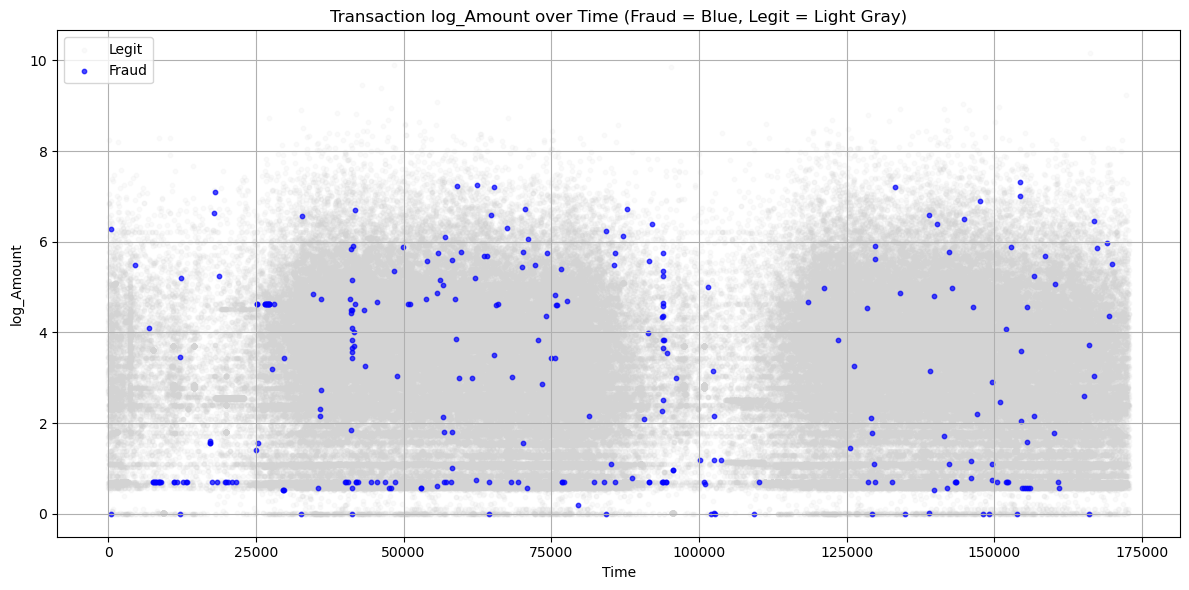

In [75]:
# Create a color map with custom transparency
colors = df['Class'].map({0: 'lightgray', 1: 'blue'})
alphas = df['Class'].map({0: 0.1, 1: 0.7})  # Lower opacity for legit, higher for fraud

# Create scatter plot
plt.figure(figsize=(12, 6))
for alpha_val in [0, 1]:
    subset = df[df['Class'] == alpha_val]
    plt.scatter(subset['Time'], subset['log_Amount'],
                c='lightgray' if alpha_val == 0 else 'blue',
                alpha=0.1 if alpha_val == 0 else 0.7,
                s=10, label='Fraud' if alpha_val == 1 else 'Legit')

# Labels and title
plt.xlabel('Time')
plt.ylabel('log_Amount')
plt.title('Transaction log_Amount over Time (Fraud = Blue, Legit = Light Gray)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

df.drop('log_Amount', axis=1 ,inplace=True)

##                 Feature Analysis - Summary
### Time & Amount:
- No clear pattern between fraud and transaction amount or time.
- Fraud occurs randomly across all amounts and time periods.
### V1 - V28:
- Features are anonymized (PCA-transformed), so traditional analysis is not applicable.
- Feature importance will be assessed using:
###   1. Logistic Regression → feature weights
###   2. Random Forest → feature importance scores
### Key Insight:
- The model itself will guide us on which features matter most during the modeling phase.

___________________________________________________________________________________________

## Logistic Regression Weights

In [76]:
X_train = df.drop(columns='Class')
y_train = df['Class']

In [77]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

# fit logistic regression
coef = model.coef_.flatten()

# Get coefficients and corresponding feature names
coef = model.coef_.flatten()
feature_names = X_train.columns

# Create and sort the coefficient DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': np.abs(coef)
}).sort_values(by='coefficient', ascending=False).reset_index(drop=True)

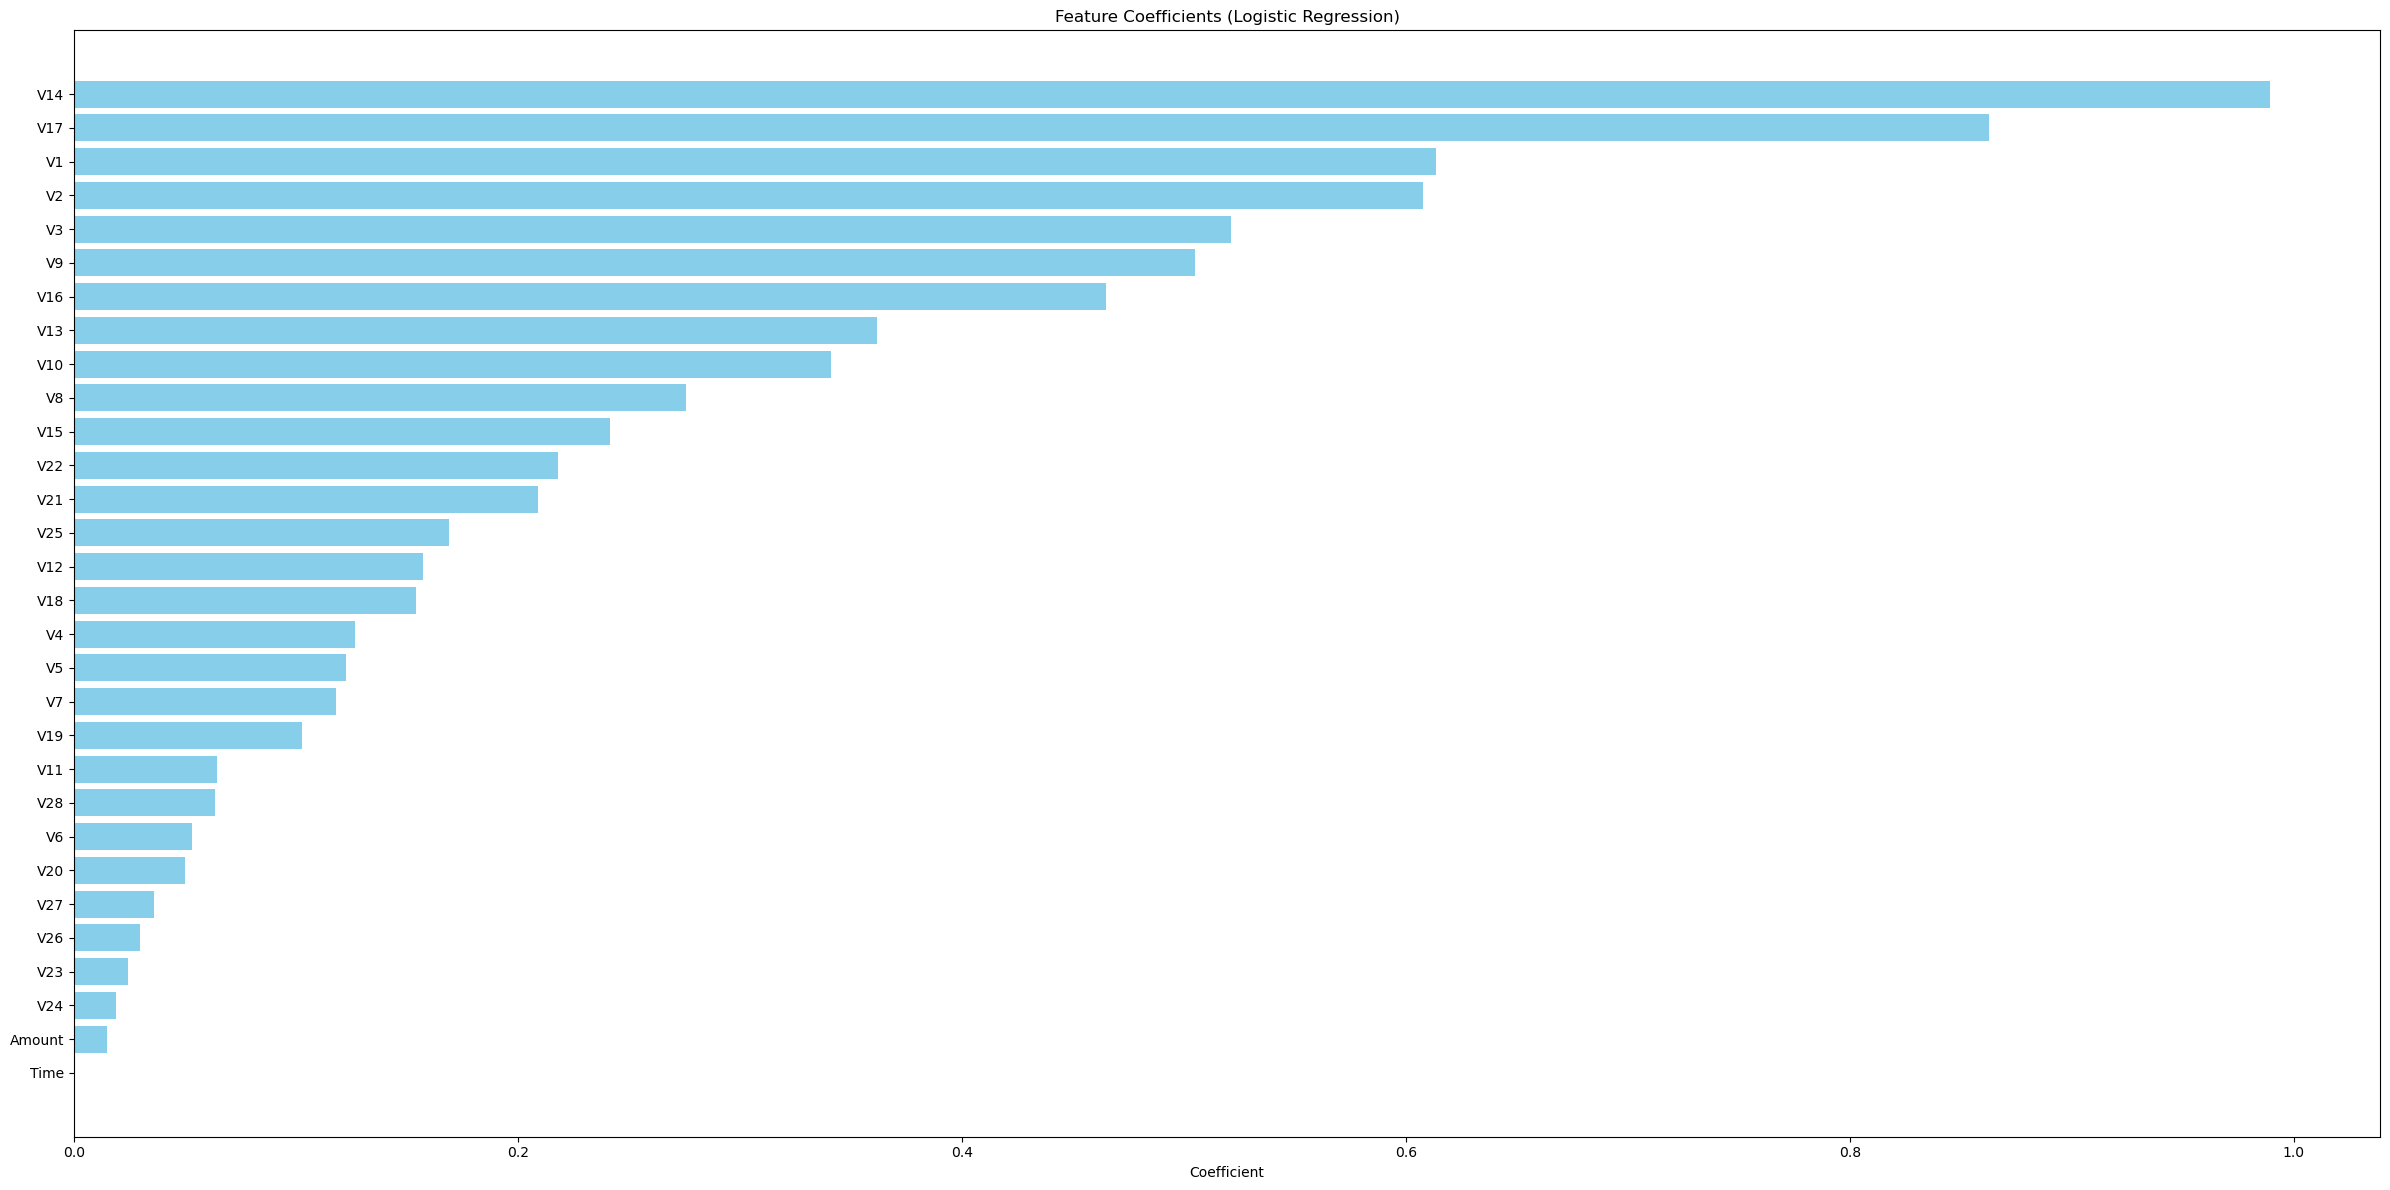

In [78]:
# Plot top features by coefficient
plt.figure(figsize=(24, 12))
plt.barh(coef_df['feature'], coef_df['coefficient'], color='skyblue')
plt.xlabel('Coefficient')
plt.title('Feature Coefficients (Logistic Regression)')
plt.gca().invert_yaxis()  # Highest coefficients at the top
plt.tight_layout()
plt.show()

##      Logistic Regression - Feature Importance Summary
### Top Features (High Impact):
- V14, V17           → Strongest indicators of fraud
- V1, V2, V3, V9    → High importance

### Low Impact Features:
- Amount, Time       → Almost no impact on fraud detection
- V24, V23, V26     → Minimal contribution

## Random Forest Importance

In [79]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Create DataFrame for feature importances
importances = rf.feature_importances_
feature_names = X_train.columns

rf_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

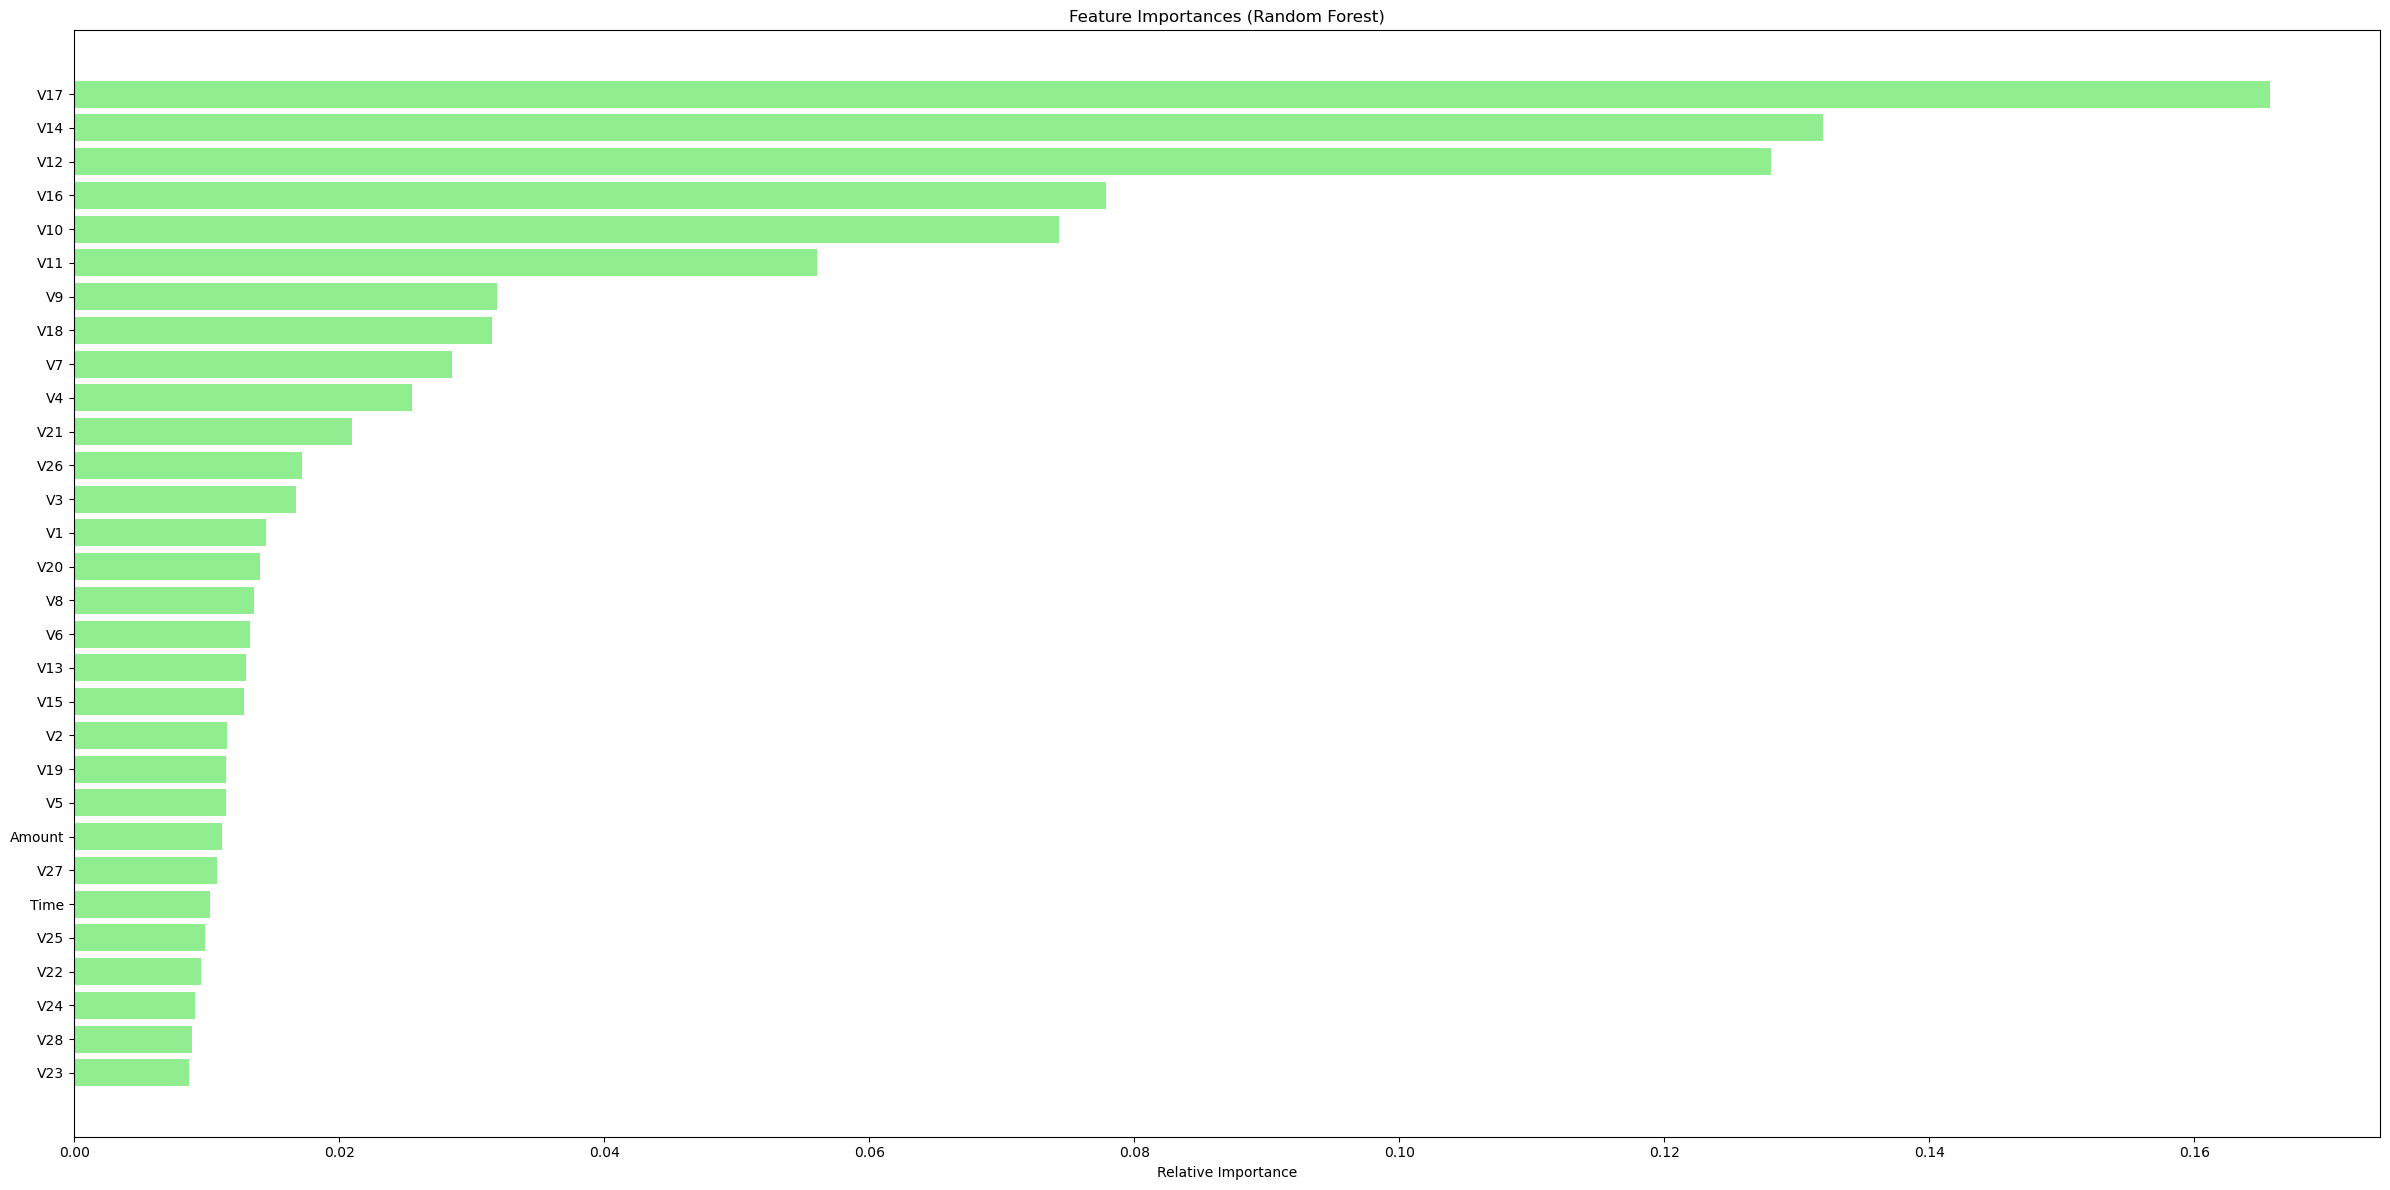

In [80]:
# Plot
plt.figure(figsize=(24, 12))
plt.title("Feature Importances (Random Forest)")
plt.barh(rf_df['feature'], rf_df['importance'], color='lightgreen')
plt.gca().invert_yaxis()  # Highest at top
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

##       Random Forest - Feature Importance Summary
### Top Features (High Impact):
- V17, V14  → Strongest fraud indicators
- V12, V16, V10, V11 → High importance
### Compared to Logistic Regression:
- V14 & V17 important in both models 
- V12 more important in RF than LR
- Amount & Time still weak but slightly more useful in RF than LR

______________________________________________________________________________________

##           Feature Importance - Key Insights
### 1. Time & Amount are weak predictors:
- Fraudsters operate across all time periods and transaction amounts with no clear pattern.

### 2. V14 & V17 are the strongest fraud indicators:
- Both LR and RF agree on their high importance,suggesting a strong signal even before PCA.

### 3. LR captures only linear relationships:
- Features like V10, V12, V16 rank lower in LR ->because their relationship with fraud is non-linear.

### 4. RF captures non-linear relationships naturally:
- Which is why V10, V12, V16 rank higher in RF ->compared to LR.

### 5. Polynomial features could boost LR performance:
- Expanding V10, V12, V16 may help LR capture the non-linear patterns that RF handles natively.

# The dataset used in this project is private and not publicly accessible.